# H4 — Environmental Concern Moderates the IT Effect (Sub-models)

H4 is tested across **four parallel logistic models**, each using a different
operationalisation of environmental orientation as the moderator.

| Sub-model | Moderator | Construct | Source |
|---|---|---|---|
| H4a | `env_concern_comp_z` | Composite environmental concern (30 items) | Milfont et al. (2006) |
| H4b | `environment_worry_z` | Affective/emotional concern | Standalone item |
| H4c | `environment_responsib_z` | Personal moral responsibility | Standalone item |
| H4d | `environment_natural_p_z` | Anthropogenic belief (cognition) | Standalone item |

**Rationale for separation:** `environment_worry`, `environment_responsib`,
and `environment_natural_p` are conceptually distinct from the Milfont NEP-based
composite — they measure affect, obligation, and causal attribution respectively,
and do not belong to any of Milfont's five subscales (Movement, Threat,
Behaviour, Utility, Growth). Conflating them would mix constructs; running them
as sub-models tests each dimension independently.

**Expected sign for all four:** β(IT_present : moderator_z) > 0
— the IT intergenerational frame should resonate more strongly with participants
who are more environmentally oriented on each dimension.


In [1]:
# ── Cell 1: Load clean data ──────────────────────────────────
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

df_mt = pd.read_csv('data/mturk_clean.csv')
df_pr = pd.read_csv('data/prolific_clean.csv')
datasets = {'mturk': df_mt, 'prolific': df_pr}
PLATFORMS = {'mturk': 'Study 1 (MTurk)', 'prolific': 'Study 2 (Prolific)'}


In [2]:
# ── Cell 2: Confirm moderator availability per dataset ────────
# The three standalone items were measured in both datasets but
# the full Milfont composite (env_concern_comp) requires the
# 30-item subscale battery which is Prolific-only.
# This cell reports which moderators are available before modelling.

H4_MODERATORS = {
    'env_concern_comp_z':    'Milfont composite (30 items)',
    'environment_worry_z':   'Affective worry (standalone)',
    'environment_responsib_z':'Personal responsibility (standalone)',
    'environment_natural_p_z':'Anthropogenic belief (standalone)',
}

print("Moderator availability by platform:\n")
for name, df in datasets.items():
    print(f"  {PLATFORMS[name]}:")
    for col, label in H4_MODERATORS.items():
        present = col in df.columns and df[col].notna().sum() > 0
        status  = '✓ available' if present else '✗ absent / all-NaN'
        print(f"    {status}  {col}  ({label})")
    print()


Moderator availability by platform:

  Study 1 (MTurk):
    ✗ absent / all-NaN  env_concern_comp_z  (Milfont composite (30 items))
    ✓ available  environment_worry_z  (Affective worry (standalone))
    ✓ available  environment_responsib_z  (Personal responsibility (standalone))
    ✓ available  environment_natural_p_z  (Anthropogenic belief (standalone))

  Study 2 (Prolific):
    ✓ available  env_concern_comp_z  (Milfont composite (30 items))
    ✓ available  environment_worry_z  (Affective worry (standalone))
    ✓ available  environment_responsib_z  (Personal responsibility (standalone))
    ✓ available  environment_natural_p_z  (Anthropogenic belief (standalone))



In [3]:
# ── Cell 3: Shared model-fitting function ────────────────────
# Logistic regression with session-clustered SEs,
# consistent with Notebooks 03 and 04 (H1–H3).

def fit_h4_submodel(df, moderator_z, label, sub_label):
    """
    Fits H4 sub-model: extraction_2 ~ IT_present * moderator_z +
                       GI_present + age + education + round

    Parameters
    ----------
    df          : DataFrame (mturk_clean or prolific_clean)
    moderator_z : str, name of the z-scored moderator column
    label       : str, platform label for printing
    sub_label   : str, e.g. 'H4a', 'H4b', ...

    Returns fitted statsmodels Results object, or None if skipped.
    """
    # Skip gracefully if column is absent or entirely missing
    if moderator_z not in df.columns or df[moderator_z].isna().all():
        print(f"  {sub_label} [{label}]: {moderator_z} absent — skipped.")
        return None

    formula = (
        f"extraction_2 ~ IT_present * {moderator_z} + "
        "GI_present + age + education + round"
    )
    data = df.dropna(subset=['extraction_2', 'IT_present', moderator_z,
                              'GI_present', 'age', 'education', 'round'])

    model = smf.logit(formula, data=data).fit(
        cov_type='cluster',
        cov_kwds={'groups': data['sessioncode']},
        disp=False
    )

    iterm = f'IT_present:{moderator_z}'
    b     = model.params.get(iterm, np.nan)
    p     = model.pvalues.get(iterm, np.nan)
    se    = model.bse.get(iterm, np.nan)
    OR    = np.exp(b)
    sig   = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'

    # H4 expected sign is positive for all sub-models
    supported = (b > 0 and p < .05)
    verdict   = '✓ SUPPORTED' if supported else '✗ NOT SUPPORTED'

    print(f"\n{'─'*60}")
    print(f"  {sub_label}: IT_present × {moderator_z}")
    print(f"  Platform : {label}")
    print(f"  N = {len(data):,}  |  Sessions = {data['sessioncode'].nunique()}")
    print(f"  β = {b:.4f}   OR = {OR:.3f}   SE = {se:.4f}   p = {p:.4f}  {sig}")
    print(f"  {verdict}")
    print(model.summary().tables[1])

    return model


In [4]:
# ── Cell 4: H4a — Milfont composite moderator ────────────────
# This is the primary H4 model: 30-item environmental concern
# composite built from Milfont et al.'s (2006) five subscales
# (Movement, Threat, Behaviour, Utility, Growth).
# Available for Prolific; MTurk run if composite is present.

model_h4a = {}
for name, df in datasets.items():
    m = fit_h4_submodel(df, 'env_concern_comp_z', PLATFORMS[name], 'H4a')
    if m is not None:
        model_h4a[name] = m


  H4a [Study 1 (MTurk)]: env_concern_comp_z absent — skipped.

────────────────────────────────────────────────────────────
  H4a: IT_present × env_concern_comp_z
  Platform : Study 2 (Prolific)
  N = 10,743  |  Sessions = 288
  β = -0.1210   OR = 0.886   SE = 0.0728   p = 0.0966  n.s.
  ✗ NOT SUPPORTED
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -1.1598      0.156     -7.452      0.000      -1.465      -0.855
IT_present                        0.3473      0.097      3.578      0.000       0.157       0.538
env_concern_comp_z                0.1445      0.052      2.790      0.005       0.043       0.246
IT_present:env_concern_comp_z    -0.1210      0.073     -1.662      0.097      -0.264       0.022
GI_present                        0.4211      0.098      4.291      0.000       0.229       0.613
age      

In [5]:
# ── Cell 5: H4b — Affective worry moderator ──────────────────
# Operationalises environmental orientation as emotional concern.
# environment_worry: single Likert item measuring anxiety/worry
# about climate change.  This is an AFFECTIVE dimension —
# distinct from belief (H4d) and obligation (H4c).
# Prediction: participants who feel worried may be more
# responsive to the IT frame's emphasis on future harm.

model_h4b = {}
for name, df in datasets.items():
    m = fit_h4_submodel(df, 'environment_worry_z', PLATFORMS[name], 'H4b')
    if m is not None:
        model_h4b[name] = m



────────────────────────────────────────────────────────────
  H4b: IT_present × environment_worry_z
  Platform : Study 1 (MTurk)
  N = 11,240  |  Sessions = 309
  β = -0.0241   OR = 0.976   SE = 0.0795   p = 0.7618  n.s.
  ✗ NOT SUPPORTED
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -1.4455      0.198     -7.315      0.000      -1.833      -1.058
IT_present                         0.4322      0.089      4.883      0.000       0.259       0.606
environment_worry_z                0.0773      0.057      1.365      0.172      -0.034       0.188
IT_present:environment_worry_z    -0.0241      0.080     -0.303      0.762      -0.180       0.132
GI_present                         0.5422      0.090      6.015      0.000       0.366       0.719
age                                0.0022      0.003      0.705   

In [6]:
# ── Cell 6: H4c — Personal responsibility moderator ──────────
# Operationalises environmental orientation as perceived moral
# obligation to act.  environment_responsib captures whether
# the participant believes they personally have a duty to address
# climate change — a norm-activation construct
# (Schwartz, 1977; Stern et al., 1999).
# Prediction: those with higher personal responsibility may be
# more receptive to the IT frame's implicit duty to future generations.

model_h4c = {}
for name, df in datasets.items():
    m = fit_h4_submodel(df, 'environment_responsib_z', PLATFORMS[name], 'H4c')
    if m is not None:
        model_h4c[name] = m



────────────────────────────────────────────────────────────
  H4c: IT_present × environment_responsib_z
  Platform : Study 1 (MTurk)
  N = 11,240  |  Sessions = 309
  β = -0.0370   OR = 0.964   SE = 0.0748   p = 0.6207  n.s.
  ✗ NOT SUPPORTED
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.4180      0.200     -7.098      0.000      -1.810      -1.026
IT_present                             0.4317      0.089      4.840      0.000       0.257       0.607
environment_responsib_z                0.0818      0.053      1.551      0.121      -0.022       0.185
IT_present:environment_responsib_z    -0.0370      0.075     -0.495      0.621      -0.184       0.110
GI_present                             0.5406      0.090      6.009      0.000       0.364       0.717
age                               

In [7]:
# ── Cell 7: H4d — Anthropogenic belief moderator ─────────────
# Operationalises environmental orientation as causal attribution:
# whether the participant believes human activity is responsible
# for environmental change.  This is a COGNITIVE dimension.
# environment_natural_p: scored so that higher = stronger
# anthropogenic belief (reverse-scored if needed in Nb01).
# Prediction: those who attribute environmental problems to humans
# may see the IT frame as more personally relevant.

model_h4d = {}
for name, df in datasets.items():
    m = fit_h4_submodel(df, 'environment_natural_p_z', PLATFORMS[name], 'H4d')
    if m is not None:
        model_h4d[name] = m



────────────────────────────────────────────────────────────
  H4d: IT_present × environment_natural_p_z
  Platform : Study 1 (MTurk)
  N = 11,240  |  Sessions = 309
  β = 0.0897   OR = 1.094   SE = 0.0700   p = 0.1999  n.s.
  ✗ NOT SUPPORTED
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.4556      0.197     -7.389      0.000      -1.842      -1.070
IT_present                             0.4310      0.089      4.852      0.000       0.257       0.605
environment_natural_p_z                0.0232      0.052      0.450      0.653      -0.078       0.125
IT_present:environment_natural_p_z     0.0897      0.070      1.282      0.200      -0.047       0.227
GI_present                             0.5452      0.090      6.060      0.000       0.369       0.722
age                                

In [8]:
# ── Cell 8: Predicted probability tables ─────────────────────
# For each sub-model, show the IT effect (Δ Pr[green]) at three
# levels of the moderator: −1 SD (low), mean, +1 SD (high).
# This converts log-odds to predicted probabilities for
# dissertation tables and plain-language interpretation.

def ame_table(df, model, moderator_z, sub_label, platform):
    """
    Returns a small DataFrame:
      Moderator level | No IT Pr | IT Pr | Δ Pr (IT effect)
    """
    data = df.dropna(subset=[moderator_z, 'age', 'education',
                              'round', 'GI_present'])
    means = {c: data[c].mean()
             for c in ['GI_present', 'age', 'education', 'round']
             if c in data.columns}

    rows = []
    for level, lbl in [(-1.0, '−1 SD (low)'),
                        ( 0.0, 'Mean'),
                        (+1.0, '+1 SD (high)')]:
        row_it0 = {moderator_z: level, 'IT_present': 0, **means}
        row_it1 = {moderator_z: level, 'IT_present': 1, **means}
        p0 = model.predict(pd.DataFrame([row_it0]))[0]
        p1 = model.predict(pd.DataFrame([row_it1]))[0]
        rows.append({
            'Moderator level': lbl,
            'No IT  Pr(green)': round(p0, 4),
            'IT     Pr(green)': round(p1, 4),
            'Δ Pr (IT effect)': round(p1 - p0, 4)
        })

    tbl = pd.DataFrame(rows).set_index('Moderator level')
    print(f"\n{sub_label} — {platform} — Predicted Pr(green)")
    print(f"Moderator: {moderator_z}")
    print(tbl.to_string())
    return tbl

all_h4 = [
    ('H4a', 'env_concern_comp_z',      model_h4a),
    ('H4b', 'environment_worry_z',     model_h4b),
    ('H4c', 'environment_responsib_z', model_h4c),
    ('H4d', 'environment_natural_p_z', model_h4d),
]

for sub_label, mod_z, mdict in all_h4:
    for name, m in mdict.items():
        if mod_z in datasets[name].columns:
            ame_table(datasets[name], m, mod_z, sub_label, PLATFORMS[name])



H4a — Study 2 (Prolific) — Predicted Pr(green)
Moderator: env_concern_comp_z
                 No IT  Pr(green)  IT     Pr(green)  Δ Pr (IT effect)
Moderator level                                                      
−1 SD (low)                0.2402            0.3356            0.0954
Mean                       0.2676            0.3408            0.0733
+1 SD (high)               0.2968            0.3461            0.0493

H4b — Study 1 (MTurk) — Predicted Pr(green)
Moderator: environment_worry_z
                 No IT  Pr(green)  IT     Pr(green)  Δ Pr (IT effect)
Moderator level                                                      
−1 SD (low)                0.2085            0.2937            0.0852
Mean                       0.2216            0.3048            0.0833
+1 SD (high)               0.2352            0.3162            0.0810

H4b — Study 2 (Prolific) — Predicted Pr(green)
Moderator: environment_worry_z
                 No IT  Pr(green)  IT     Pr(green)  Δ Pr (IT effec

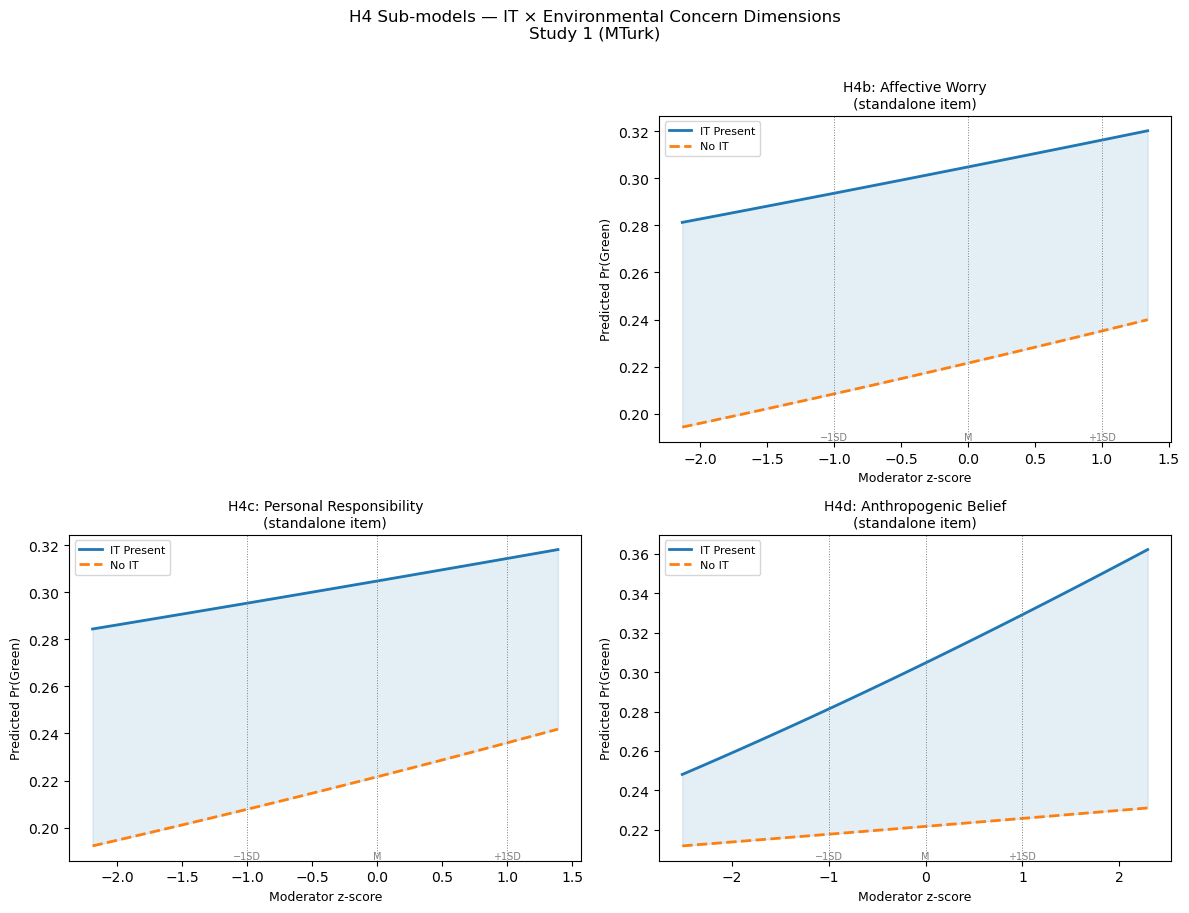

Saved: outputs/fig_h4_all_submodels_mturk.png


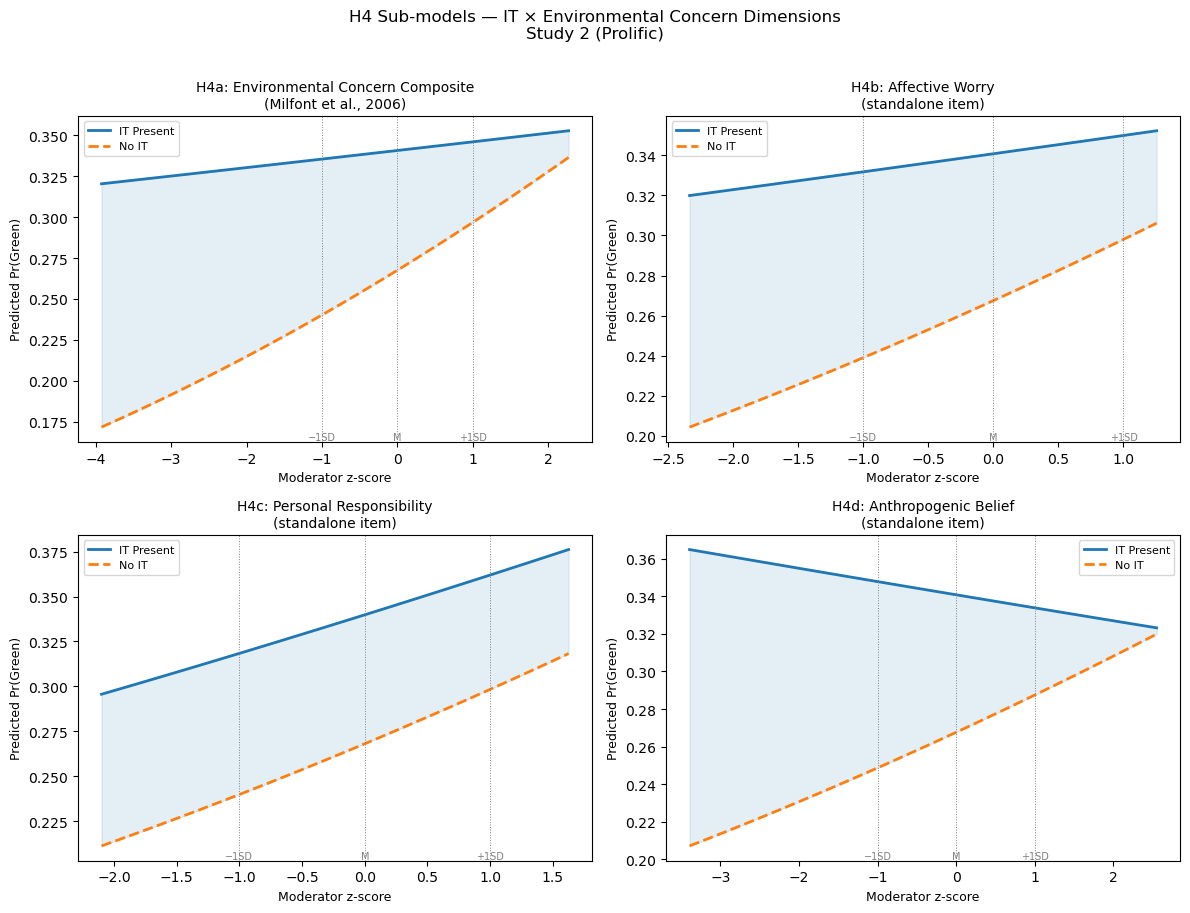

Saved: outputs/fig_h4_all_submodels_prolific.png


In [9]:
# ── Cell 9: Marginal effects plot — all four sub-models ──────
# 4-panel figure (2×2): one panel per sub-model.
# Each panel shows predicted Pr(green) across the moderator range
# for IT_present = 1 (solid) vs IT_present = 0 (dashed).
# One figure per platform.

SUB_MODELS = [
    ('H4a', 'env_concern_comp_z',
     'Environmental Concern Composite\n(Milfont et al., 2006)'),
    ('H4b', 'environment_worry_z',
     'Affective Worry\n(standalone item)'),
    ('H4c', 'environment_responsib_z',
     'Personal Responsibility\n(standalone item)'),
    ('H4d', 'environment_natural_p_z',
     'Anthropogenic Belief\n(standalone item)'),
]
MODEL_DICTS = [model_h4a, model_h4b, model_h4c, model_h4d]

for name, df in datasets.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()

    for ax, (sub_label, mod_z, panel_title), mdict in zip(
            axes, SUB_MODELS, MODEL_DICTS):

        if name not in mdict or mod_z not in df.columns:
            ax.set_visible(False)
            continue

        model = mdict[name]
        data  = df.dropna(subset=[mod_z])
        mod_range = np.linspace(data[mod_z].min(),
                                 data[mod_z].max(), 100)
        means = {c: data[c].mean()
                 for c in ['GI_present', 'age', 'education', 'round']
                 if c in data.columns}

        pred_it1, pred_it0 = [], []
        for mv in mod_range:
            r0 = {mod_z: mv, 'IT_present': 0, **means}
            r1 = {mod_z: mv, 'IT_present': 1, **means}
            pred_it0.append(model.predict(pd.DataFrame([r0]))[0])
            pred_it1.append(model.predict(pd.DataFrame([r1]))[0])

        ax.plot(mod_range, pred_it1, color='#1f77b4', lw=2,
                label='IT Present')
        ax.plot(mod_range, pred_it0, color='#ff7f0e', lw=2,
                linestyle='--', label='No IT')
        ax.fill_between(mod_range, pred_it0, pred_it1,
                        alpha=0.12, color='#1f77b4')

        # Mark −1 SD, mean, +1 SD on x-axis
        for xval, lbl in [(-1, '−1SD'), (0, 'M'), (1, '+1SD')]:
            ax.axvline(xval, color='grey', lw=0.7, linestyle=':')
            ax.text(xval, ax.get_ylim()[0], lbl,
                    ha='center', va='bottom', fontsize=7, color='grey')

        ax.set_title(f'{sub_label}: {panel_title}', fontsize=10)
        ax.set_xlabel('Moderator z-score', fontsize=9)
        ax.set_ylabel('Predicted Pr(Green)', fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle(
        f'H4 Sub-models — IT × Environmental Concern Dimensions\n'
        f'{PLATFORMS[name]}',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    fname = f'outputs/fig_h4_all_submodels_{name}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


In [10]:
# ── Cell 10: H4 summary table — all sub-models ──────────────
# Collects the key coefficient, OR, SE, p, and support verdict
# for every sub-model × platform combination into one DataFrame.
# Save as CSV for the dissertation appendix.

rows = []
for sub_label, mod_z, mdict in all_h4:
    iterm = f'IT_present:{mod_z}'
    for name, m in mdict.items():
        b   = m.params.get(iterm, np.nan)
        p   = m.pvalues.get(iterm, np.nan)
        se  = m.bse.get(iterm, np.nan)
        OR  = round(np.exp(b), 3) if not np.isnan(b) else np.nan
        sig = ('***' if p < .001 else '**' if p < .01
               else '*'  if p < .05 else 'n.s.')
        rows.append({
            'Sub-model':  sub_label,
            'Moderator':  mod_z,
            'Platform':   PLATFORMS[name],
            'log-odds β': round(b, 4),
            'OR':         OR,
            'SE':         round(se, 4),
            'p':          round(p, 4),
            'Sig':        sig,
            'Supported':  '✓' if (b > 0 and p < .05) else '✗'
        })

summary_h4 = pd.DataFrame(rows)
print("\n=== H4 Sub-model Summary ===")
print(summary_h4.to_string(index=False))

summary_h4.to_csv('outputs/h4_submodel_summary.csv', index=False)
print("\nSaved: outputs/h4_submodel_summary.csv")



=== H4 Sub-model Summary ===
Sub-model               Moderator           Platform  log-odds β    OR     SE      p  Sig Supported
      H4a      env_concern_comp_z Study 2 (Prolific)     -0.1210 0.886 0.0728 0.0966 n.s.         ✗
      H4b     environment_worry_z    Study 1 (MTurk)     -0.0241 0.976 0.0795 0.7618 n.s.         ✗
      H4b     environment_worry_z Study 2 (Prolific)     -0.1102 0.896 0.0750 0.1416 n.s.         ✗
      H4c environment_responsib_z    Study 1 (MTurk)     -0.0370 0.964 0.0748 0.6207 n.s.         ✗
      H4c environment_responsib_z Study 2 (Prolific)     -0.0520 0.949 0.0748 0.4868 n.s.         ✗
      H4d environment_natural_p_z    Study 1 (MTurk)      0.0897 1.094 0.0700 0.1999 n.s.         ✗
      H4d environment_natural_p_z Study 2 (Prolific)     -0.1302 0.878 0.0721 0.0711 n.s.         ✗

Saved: outputs/h4_submodel_summary.csv
